# 3.2.4 模板匹配（路径 B1）：聚类原型

**核心思路**：按 EFPI 逐帧标签将 z_t 分组取均值，得到 65 个阵型的聚类原型 μ_k。

不依赖主流阵型白名单，通过时间一致性自动识别主流阵型。

## 1. 环境设置与导入

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict
import pickle, json, warnings
from scipy.spatial import Delaunay
from scipy.spatial.distance import cdist
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(42); np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}  CUDA: {torch.cuda.is_available()}  Device: {device}')

PyTorch: 2.9.1+cpu  CUDA: False  Device: cpu


## 2. 加载数据

In [2]:
base_path = Path(r'E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH')
data_path  = base_path / 'data' / 'morph_test' / 'bgnn_dataset'
bgnn_data  = base_path / 'data' / 'morph_test' / 'bgnn_data'
efpi_path  = base_path / 'data' / 'morph_test' / 'efpi_baseline'
model_dir  = base_path / 'Step3_Probabilistic_Identification' / '3.2_Probabilistic_Model' / 'Test'

with open(data_path / 'graph_dataset_10517_full.pkl', 'rb') as f:
    raw = pickle.load(f)
all_graphs = [g for g in raw if not torch.isnan(g.x).any()]

def get_fid(g):
    fid = g.frame_id
    return fid if isinstance(fid, int) else int(fid.item())

all_graphs.sort(key=get_fid)
print(f'有效图: {len(all_graphs)}  fid: {get_fid(all_graphs[0])} ~ {get_fid(all_graphs[-1])}')

with open(data_path / 'dataset_metadata_10517_full.json') as f:
    metadata = json.load(f)
num_classes = metadata.get('n_formations', 65)

with open(bgnn_data / 'formation_mapping.pkl', 'rb') as f:
    fm = pickle.load(f)
formation_to_idx = fm['formation_to_idx']
idx_to_formation = fm['idx_to_formation']

efpi_df = pd.read_parquet(efpi_path / 'efpi_baseline_results_10517_fullmatch.parquet')
efpi_h1 = efpi_df[(efpi_df['team_id'].astype(str) == '364') & (efpi_df['period_id'] == 1)].drop_duplicates('frame_id')
efpi_fid2form = dict(zip(efpi_h1['frame_id'].astype(int), efpi_h1['formation'].astype(str)))

sg = all_graphs[0]
NODE_DIM   = sg.x.shape[1]
GLOBAL_DIM = sg.global_features.shape[-1]
print(f'节点特征: {NODE_DIM}  全局特征: {GLOBAL_DIM}  阵型数: {num_classes}')
print(f'EFPI Period1 帧数: {len(efpi_fid2form)}')

有效图: 49928  fid: 4630 ~ 98893
节点特征: 41  全局特征: 24  阵型数: 65
EFPI Period1 帧数: 50084


## 3. Stage 1 模型定义与加载

In [3]:
class GraphConvModule(nn.Module):
    def __init__(self, ic, hc, oc):
        super().__init__()
        self.c1, self.b1 = GCNConv(ic, hc), nn.BatchNorm1d(hc)
        self.c2, self.b2 = GCNConv(hc, oc), nn.BatchNorm1d(oc)
    def forward(self, x, ei):
        x = F.relu(self.b1(self.c1(x, ei)))
        x = F.dropout(x, p=0.3, training=self.training)
        return self.b2(self.c2(x, ei))

class GlobalFeatureFusion(nn.Module):
    def __init__(self, gd, gl, fd):
        super().__init__()
        self.fg = nn.Linear(gd, fd); self.fl = nn.Linear(gl, fd); self.bn = nn.BatchNorm1d(fd)
    def forward(self, ge, gf):
        if gf.dim() == 3: gf = gf.squeeze(1)
        return F.relu(self.bn(self.fg(ge) + self.fl(gf)))

class MCDropout(nn.Module):
    def __init__(self, p=0.5): super().__init__(); self.p = p
    def forward(self, x): return F.dropout(x, p=self.p, training=True)

class BGNN(nn.Module):
    def __init__(self, nd, gd, hd, nc):
        super().__init__()
        self.gcm = GraphConvModule(nd, hd, hd)
        self.fus = GlobalFeatureFusion(hd, gd, hd)
        self.mcd = MCDropout(0.5)
        self.cls = nn.Sequential(nn.Linear(hd,hd), nn.ReLU(), nn.Dropout(0.3), nn.Linear(hd,nc))
    def forward(self, data):
        ne = self.gcm(data.x, data.edge_index)
        ge = global_mean_pool(ne, data.batch)
        z  = self.fus(ge, data.global_features)
        return self.cls(self.mcd(z))
    def embed(self, data):
        ne = self.gcm(data.x, data.edge_index)
        ge = global_mean_pool(ne, data.batch)
        return self.fus(ge, data.global_features)
    def embed_mc(self, data):
        """方案A：推断期保持 MCDropout 激活，用于不确定性量化"""
        ne = self.gcm(data.x, data.edge_index)
        ge = global_mean_pool(ne, data.batch)
        return self.mcd(self.fus(ge, data.global_features))

stage1 = BGNN(NODE_DIM, GLOBAL_DIM, 128, num_classes).to(device)
# 优先 best_model.pth（24维，3.2.3 重新训练）；fallback stage1_encoder.pth
for _cand in ['best_model.pth', 'stage1_encoder.pth']:
    w_path = model_dir / _cand
    if w_path.exists():
        break
stage1.load_state_dict(torch.load(w_path, map_location=device))
stage1.eval()
for p in stage1.parameters(): p.requires_grad = False
print(f'[OK] Stage 1 加载自: {w_path.name}  参数: {sum(p.numel() for p in stage1.parameters()):,} (冻结)')

[OK] Stage 1 加载自: best_model.pth  参数: 67,265 (冻结)


## 4. 稳定性分数

In [4]:
VL_S, VL_E = 29, 34  # vertical_level 特征列范围

def stab_score(g):
    lv  = g.x[:, VL_S:VL_E].argmax(dim=1)
    cnt = torch.zeros(5)
    for l in range(5): cnt[l] = (lv == l).sum()
    act = cnt[cnt > 0]
    if len(act) == 0: return 0.0
    return (1.0 / len(act)) * (act.min().item() / 3.0)

print('计算稳定性分数...')
stab_all = np.array([stab_score(g) for g in all_graphs], dtype=np.float32)
stab_t   = torch.tensor(stab_all, dtype=torch.float32)
print(f'stability mean={stab_all.mean():.3f}  std={stab_all.std():.3f}')

计算稳定性分数...
stability mean=0.072  std=0.019


## 5. 批量提取 z_t

In [5]:
BATCH_EXT = 512 if device.type == "cuda" else 256
N_MC = 50  # 方案A：MC Dropout 采样次数（用于 Cell 14）
loader_ext = DataLoader(all_graphs, batch_size=BATCH_EXT, shuffle=False)

# 确定性 z_t：用于原型 μ_k 计算（不含 MCDropout，保证原型质量）
all_z, all_fids_list = [], []
print(f'提取确定性 z_t（用于原型计算，device={device}, batch={BATCH_EXT})...')
with torch.no_grad():
    for batch in loader_ext:
        batch = batch.to(device)
        all_z.append(stage1.embed(batch).cpu())
        fids = batch.frame_id
        if isinstance(fids, torch.Tensor):
            all_fids_list.extend(fids.cpu().tolist())
        else:
            all_fids_list.extend([f.item() if hasattr(f,'item') else f for f in fids])

all_z    = torch.cat(all_z, dim=0)
all_fids = np.array(all_fids_list, dtype=int)
print(f'[OK] z_t shape: {all_z.shape}  （确定性嵌入，方案A MC采样将在 Cell 14 执行）')

提取确定性 z_t（用于原型计算，device=cpu, batch=256)...
[OK] z_t shape: torch.Size([49928, 128])  （确定性嵌入，方案A MC采样将在 Cell 14 执行）


## 6. B1：聚类原型计算

按 EFPI 标签分组，取 z_t 均值作为原型嵌入 μ_k。

In [6]:
form2zs = defaultdict(list)
for fid, z in zip(all_fids.tolist(), all_z):
    form = efpi_fid2form.get(fid)
    if form is not None: form2zs[form].append(z)

ALL_FORMS = sorted(formation_to_idx.keys(), key=lambda f: formation_to_idx[f])
available_forms = [f for f in ALL_FORMS if f in form2zs]
missing_forms   = [f for f in ALL_FORMS if f not in form2zs]

proto_dict  = {f: torch.stack(form2zs[f]).mean(0) for f in available_forms}
proto_mat   = torch.stack([proto_dict[f] for f in available_forms])  # (F, 128)
proto_mat_n = F.normalize(proto_mat, dim=-1)

print(f'原型数量: {len(available_forms)} / {len(ALL_FORMS)}  缺失: {len(missing_forms)}')
print(f'原型矩阵: {proto_mat.shape}')
print(f'Top-10 阵型（按帧数）:')
for f in sorted(available_forms, key=lambda f: -len(form2zs[f]))[:10]:
    print(f'  {f:<12} {len(form2zs[f]):>5} 帧')

原型数量: 43 / 65  缺失: 22
原型矩阵: torch.Size([43, 128])
Top-10 阵型（按帧数）:
  442           5537 帧
  2431          3573 帧
  42121         3314 帧
  1234          3297 帧
  433           2724 帧
  3421          2552 帧
  343           2482 帧
  343flat       2429 帧
  4321          2253 帧
  31213         2192 帧


## 7. 温度参数设置与帧级相似度

In [7]:
TAU = 0.07  # 温度参数（推荐 0.05~0.15）

# ─── 方案 A: MC Dropout 帧级概率 ─────────────────────────────────────────────
# 对每帧运行 N_MC 次带 MCDropout 的前向传播，取概率均值/方差
# 参考：Gal & Ghahramani 2016，MCDropout 近似变分推断
print(f'[方案 A] MC Dropout 采样 N={N_MC} 次，提取帧级概率分布...')
all_z_mc_list = []
with torch.no_grad():
    for n in range(N_MC):
        z_mc_n = []
        for batch in loader_ext:
            batch = batch.to(device)
            z_mc_n.append(stage1.embed_mc(batch).cpu())
        all_z_mc_list.append(torch.cat(z_mc_n, dim=0))  # (N, 128)
        if (n + 1) % 10 == 0:
            print(f'  采样进度: {n+1}/{N_MC}')

all_z_mc = torch.stack(all_z_mc_list)          # (N_MC, N, 128)
z_mc_norm = F.normalize(all_z_mc, dim=-1)       # (N_MC, N, 128)
cos_mc    = torch.einsum('mni,ki->mnk',
                z_mc_norm, proto_mat_n.cpu())    # (N_MC, N, K)
probs_mc  = F.softmax(cos_mc / TAU, dim=-1)     # (N_MC, N, K)

frame_probs     = probs_mc.mean(0)              # (N, K) 方案A后验均值
frame_probs_var = probs_mc.var(0)               # (N, K) 认知不确定性
frame_epistemic = frame_probs_var.max(dim=-1).values  # (N,) 帧级最大方差
print(f'[OK] frame_probs shape: {frame_probs.shape}')
print(f'[OK] 帧级认知不确定性 - 均值: {frame_epistemic.mean():.6f}  最大: {frame_epistemic.max():.6f}')

# Top-1 与 EFPI 一致率验证
top1_idx   = frame_probs.argmax(dim=-1)
top1_forms = [available_forms[i] for i in top1_idx.tolist()]
match, total = 0, 0
for fid, pred in zip(all_fids.tolist(), top1_forms):
    gt = efpi_fid2form.get(fid)
    if gt and gt in available_forms:
        total += 1
        if pred == gt: match += 1
print(f'Top-1 与 EFPI 一致率: {match}/{total} = {match/max(total,1):.3f}')

# 样本帧展示
idx = len(all_fids) // 2
print(f'\n样本帧 {all_fids[idx]} Top-8:')
top8 = frame_probs[idx].topk(8)
for val, i in zip(top8.values, top8.indices):
    print(f'  {available_forms[i]:<12} prob={val:.4f}  var={frame_probs_var[idx, i]:.6f}')


[方案 A] MC Dropout 采样 N=50 次，提取帧级概率分布...
  采样进度: 10/50
  采样进度: 20/50
  采样进度: 30/50
  采样进度: 40/50
  采样进度: 50/50
[OK] frame_probs shape: torch.Size([49928, 43])
[OK] 帧级认知不确定性 - 均值: 0.016306  最大: 0.067324
Top-1 与 EFPI 一致率: 37512/49928 = 0.751

样本帧 55502 Top-8:
  3412flat     prob=0.3340  var=0.015369
  3241         prob=0.1553  var=0.007374
  3331         prob=0.0739  var=0.002264
  31213        prob=0.0630  var=0.001533
  1423         prob=0.0427  var=0.001936
  1324         prob=0.0389  var=0.000682
  541          prob=0.0319  var=0.000523
  3511flat     prob=0.0312  var=0.000220


## 8. 温度参数敏感性分析

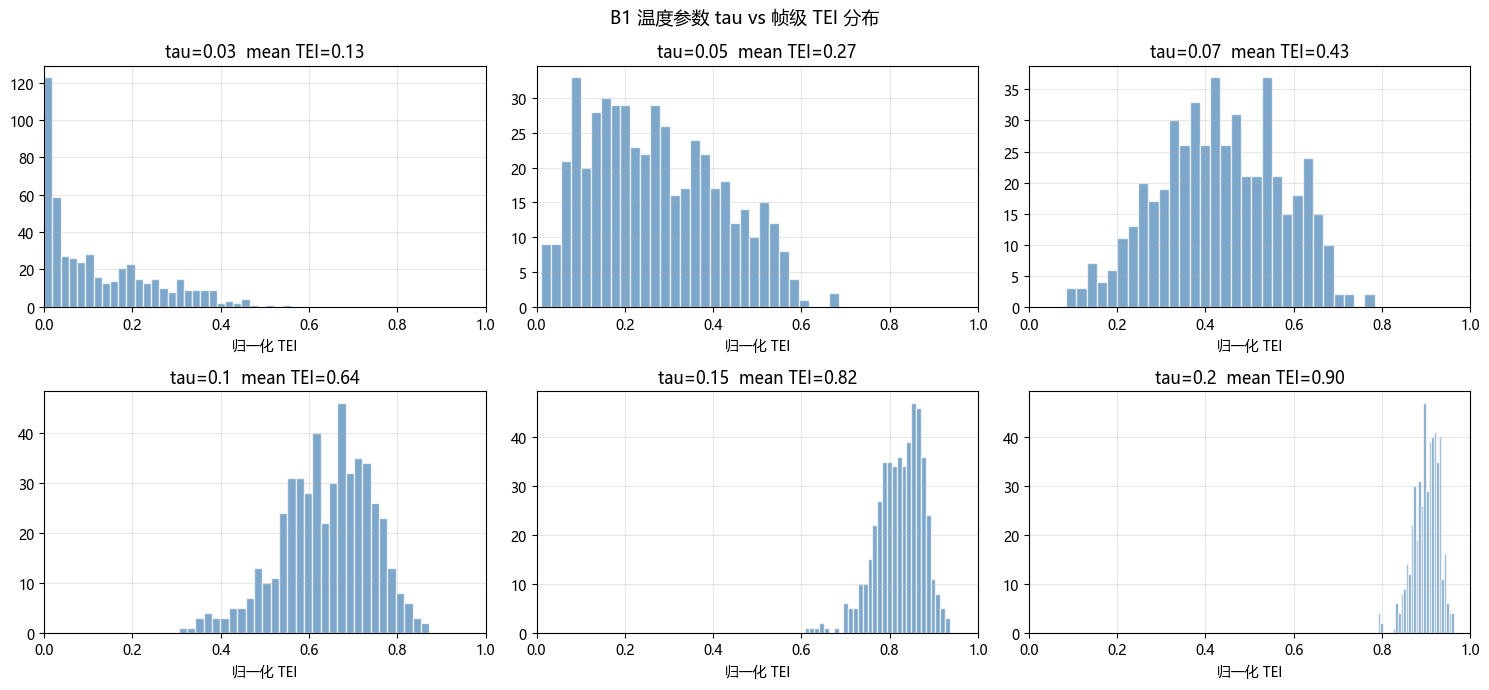

In [8]:
taus = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20]
sample_cos = (F.normalize(all_z[::100], dim=-1)) @ proto_mat_n.T
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, tau in zip(axes.flat, taus):
    p = F.softmax(sample_cos / tau, dim=-1).numpy()
    ent = (-p * np.log(p + 1e-10)).sum(axis=1)
    tei_n = ent / np.log(max(len(available_forms), 2))
    ax.hist(tei_n, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(f'tau={tau}  mean TEI={tei_n.mean():.2f}')
    ax.set_xlabel('归一化 TEI'); ax.set_xlim(0, 1); ax.grid(alpha=0.3)
plt.suptitle('B1 温度参数 tau vs 帧级 TEI 分布', fontsize=13)
plt.tight_layout()
plt.savefig(model_dir / 'b1_tau_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 窗口聚合与时间一致性分析

In [9]:
WINDOW, STRIDE = 300, 75
K = len(available_forms)
N = len(frame_probs)

# ── GM-TEI 几何特征预提取 ───────────────────────────────────────────────
# global_features 索引（24维）：
#   15: Spread  17: LpW  18: hull_area  19: compactness
#   20: DLH     21: HPL  22: LR         23: Rectangularity
print("[GM-TEI] 预提取几何特征数组...")
gf_all = torch.stack([g.global_features.squeeze(0) for g in all_graphs])  # (N, 24)
assert gf_all.shape[1] >= 24, f"global_features 维度 {gf_all.shape[1]} < 24，请先重跑 3.2.2"
spread_arr  = gf_all[:, 15].numpy()
lpw_arr     = gf_all[:, 17].numpy()
hull_arr    = gf_all[:, 18].numpy()
compact_arr = gf_all[:, 19].numpy()
dlh_arr     = gf_all[:, 20].numpy()
hpl_arr     = gf_all[:, 21].numpy()
lr_arr      = gf_all[:, 22].numpy()
rect_arr    = gf_all[:, 23].numpy()
print(f"[GM-TEI] 几何特征已提取，shape: {gf_all.shape}")

# ── 方案 B: Dirichlet-Multinomial 窗口聚合 ──────────────────────────────
# Dirichlet 是多项分布的共轭先验；以稳定性加权 top-1 频数更新均匀先验，
# 输出后验均值（替代原稳定性加权均值）及后验方差（窗口级不确定性）
window_results = []
for s in range(0, N - WINDOW + 1, STRIDE):
    e = s + WINDOW

    top1_win = frame_probs[s:e].argmax(dim=-1)  # (WINDOW,) 每帧 top-1 索引
    s_win    = stab_t[s:e]                       # (WINDOW,) 稳定性权重

    # 稳定性加权频数（每帧投票权重 ∝ 稳定性分数）
    n_k = torch.zeros(K)
    n_k.scatter_add_(0, top1_win, s_win.cpu())

    alpha_0  = torch.ones(K)                     # 均匀先验 Dir(1,1,...,1)
    alpha    = alpha_0 + n_k                     # 后验参数
    P_win    = alpha / alpha.sum()               # 后验均值（最终窗口概率）

    # Dirichlet 后验方差
    alpha_s  = alpha.sum()
    P_win_var = (alpha * (alpha_s - alpha)) / (alpha_s ** 2 * (alpha_s + 1))

    # 窗口级几何特征（取均值，用于 GM-TEI）
    geom = {
        "spread":  float(spread_arr[s:e].mean()),
        "lpw":     float(lpw_arr[s:e].mean()),
        "hull":    float(hull_arr[s:e].mean()),
        "compact": float(compact_arr[s:e].mean()),
        "dlh":     float(dlh_arr[s:e].mean()),
        "hpl":     float(hpl_arr[s:e].mean()),
        "lr":      float(lr_arr[s:e].mean()),
        "rect":    float(rect_arr[s:e].mean()),
    }

    window_results.append({
        "s": s, "e": e,
        "center_fid": int(all_fids[(s + e) // 2]),
        "probs":     P_win,
        "probs_var": P_win_var,
        "alpha":     alpha,
        "geom":      geom,
    })

print(f"[方案 B] Dirichlet 窗口聚合完成，窗口数: {len(window_results)}")

# ── TacDir 计算 ──────────────────────────────────────────────────────────
# TacDir(t) = sign(ΔDLH + ΔHPL)，5 窗口滑动平均后取符号，减少短暂震荡
dlh_seq  = np.array([w["geom"]["dlh"] for w in window_results])
hpl_seq  = np.array([w["geom"]["hpl"] for w in window_results])
delta    = (np.diff(np.concatenate([[dlh_seq[0]], dlh_seq])) +
            np.diff(np.concatenate([[hpl_seq[0]], hpl_seq])))  # (W,)
delta_sm = np.convolve(delta, np.ones(5) / 5, mode="same")    # 5 窗口平滑
tac_dir  = np.sign(delta_sm).astype(float)                    # +1 / 0 / -1
for i, w in enumerate(window_results):
    w["tac_dir"] = tac_dir[i]
print(f"[GM-TEI] TacDir  +1(进攻): {(tac_dir>0).sum()}  "
      f"-1(防守): {(tac_dir<0).sum()}  0(中性): {(tac_dir==0).sum()}")

all_P       = torch.stack([w["probs"] for w in window_results])
mean_prob   = all_P.mean(dim=0)
std_prob    = all_P.std(dim=0)
cv_prob     = std_prob / (mean_prob + 1e-8)

THRESHOLD = 0.03
mainstream_idx = (mean_prob > THRESHOLD).nonzero(as_tuple=True)[0]
mainstream_detected = sorted(
    [(available_forms[k], mean_prob[k].item(), cv_prob[k].item())
     for k in mainstream_idx.tolist()], key=lambda x: -x[1])

print(f'识别出的主流阵型（均值概率 > {THRESHOLD}）:')
print(f'{"阵型":<12} {"均值概率":>8}  {"变异系数":>8}')
print('-' * 40)
for name, mean, cv in mainstream_detected:
    print(f'{name:<12} {mean:>8.4f}  {cv:>8.3f}')


[GM-TEI] 预提取几何特征数组...
[GM-TEI] 几何特征已提取，shape: torch.Size([49928, 24])
[方案 B] Dirichlet 窗口聚合完成，窗口数: 662
[GM-TEI] TacDir  +1(进攻): 319  -1(防守): 343  0(中性): 0
识别出的主流阵型（均值概率 > 0.03）:
阵型               均值概率      变异系数
----------------------------------------
442            0.0492     1.860
42121          0.0349     1.913
1234           0.0346     1.937
433            0.0320     1.883
3421           0.0315     2.021
2431           0.0303     1.777


## 10. 可视化

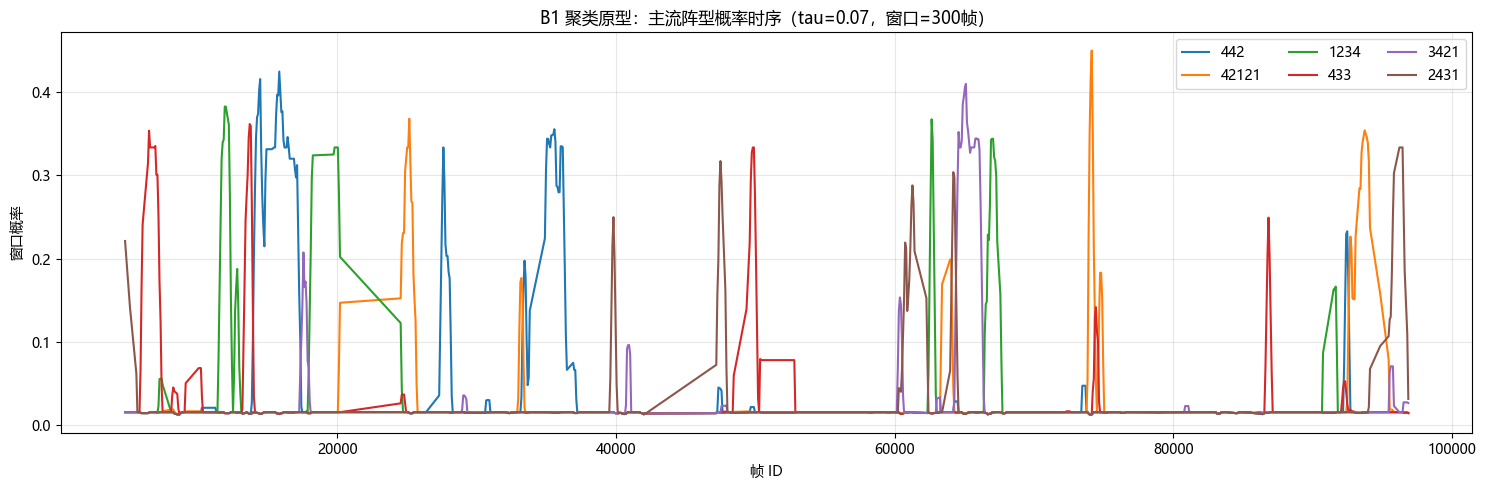

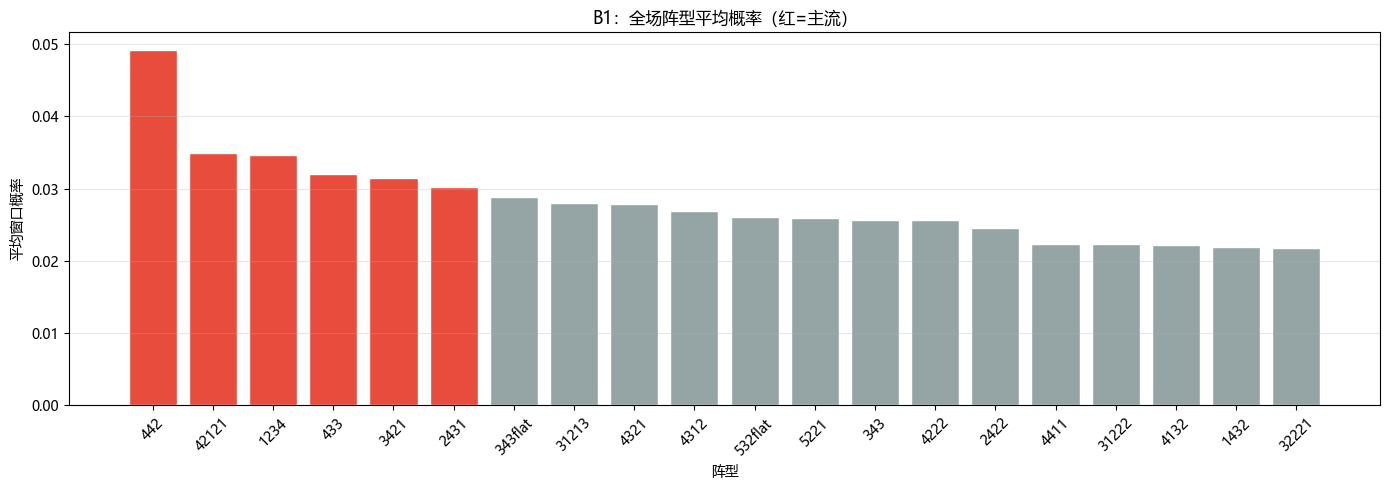

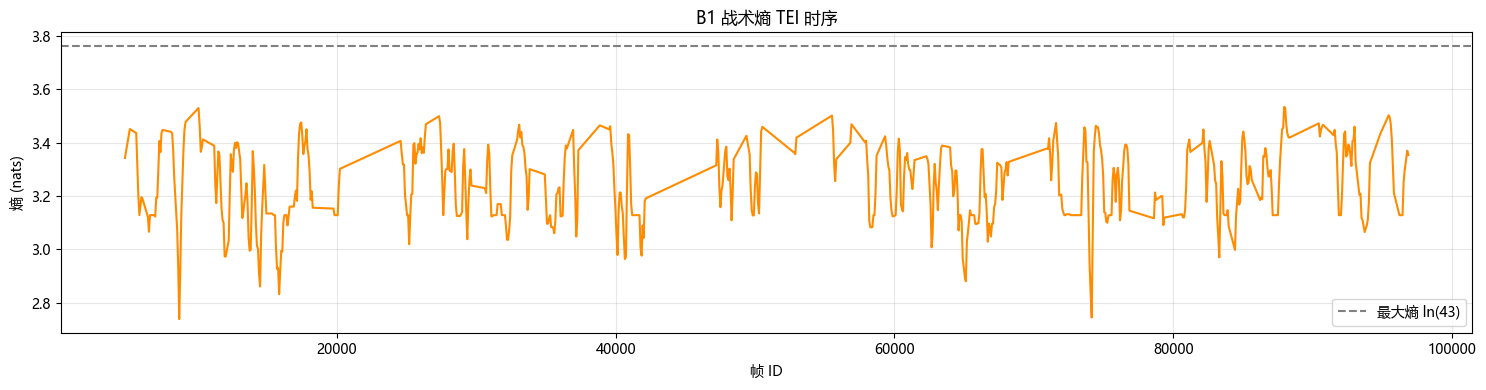

In [10]:
center_fids = [w['center_fid'] for w in window_results]
top_forms = [x[0] for x in mainstream_detected[:6]]

fig, ax = plt.subplots(figsize=(15, 5))
for form in top_forms:
    if form in available_forms:
        k = available_forms.index(form)
        y = [w['probs'][k].item() for w in window_results]
        ax.plot(center_fids, y, label=form, linewidth=1.5)
ax.set_xlabel('帧 ID'); ax.set_ylabel('窗口概率')
ax.set_title(f'B1 聚类原型：主流阵型概率时序（tau={TAU}，窗口=300帧）')
ax.legend(loc='upper right', ncol=3); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / 'b1_formation_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
srt = sorted(zip(available_forms, mean_prob.tolist()), key=lambda x: -x[1])[:20]
names, probs = zip(*srt)
ms_names = [x[0] for x in mainstream_detected]
colors = ['#e74c3c' if n in ms_names else '#95a5a6' for n in names]
ax.bar(names, probs, color=colors, edgecolor='white')
ax.set_xlabel('阵型'); ax.set_ylabel('平均窗口概率')
ax.set_title('B1：全场阵型平均概率（红=主流）')
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / 'b1_formation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

tei_series = [(-w['probs'].clamp(min=1e-10) * w['probs'].clamp(min=1e-10).log()).sum().item()
               for w in window_results]
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(center_fids, tei_series, color='darkorange', linewidth=1.5)
ax.axhline(np.log(len(available_forms)), color='gray', linestyle='--',
           label=f'最大熵 ln({len(available_forms)})')
ax.set_xlabel('帧 ID'); ax.set_ylabel('熵 (nats)')
ax.set_title('B1 战术熵 TEI 时序')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / 'b1_tei_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 保存结果

In [11]:
TAG  = "b1"
BETA = 0.5  # GM-TEI_AB 调制系数 β

# ── GM-TEI 归一化参数（跨窗口 min-max 归一化） ──────────────────────────
def _safe_norm(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-8)

_geom_keys = ["spread", "lpw", "hull", "compact", "lr", "rect"]
_geom_arrs = {k: np.array([w["geom"][k] for w in window_results]) for k in _geom_keys}
_geom_norm = {k: _safe_norm(_geom_arrs[k]) for k in _geom_keys}
spread_max = _geom_arrs["spread"].max() + 1e-8

# GM-TEI_CB 权重向量（均匀初始化 1/6，待贝叶斯学习后更新）
# g'(t) = [Spread, LpW, hull_area, compactness, LR, Rect]（均已归一化到 [0,1]）
# 注：DLH/HPL 已通过 TacDir 引入，g'(t) 中不重复计入
W_CB = np.ones(6, dtype=np.float32) / 6

torch.save({"prototypes": proto_dict,
            "available_forms": available_forms,
            "proto_matrix": proto_mat,
            "proto_matrix_normalized": proto_mat_n,
            "tau": TAU,
            "n_mc": N_MC}, model_dir / "b1_prototypes.pth")

records = []
for i, w in enumerate(window_results):
    row = {"center_fid": w["center_fid"], "window_start": w["s"], "window_end": w["e"]}
    for k, f in enumerate(available_forms):
        row[f"prob_{f}"]    = w["probs"][k].item()
        row[f"probvar_{f}"] = w["probs_var"][k].item()   # 方案B Dirichlet后验方差
    p = w["probs"].clamp(min=1e-10)
    H = (-p * p.log()).sum().item()                       # 基础 Shannon 熵 H(t)
    row["tei"] = H

    # 几何特征（窗口均值）
    row["spread_mean"] = w["geom"]["spread"]
    row["dlh_mean"]    = w["geom"]["dlh"]
    row["hpl_mean"]    = w["geom"]["hpl"]
    row["lr_mean"]     = w["geom"]["lr"]
    row["rect_mean"]   = w["geom"]["rect"]
    row["tac_dir"]     = w["tac_dir"]

    # GM-TEI_AB = H × (1 + β × Spread/Spread_max) × TacDir
    row["gm_tei_ab"] = H * (1.0 + BETA * w["geom"]["spread"] / spread_max) * w["tac_dir"]

    # GM-TEI_CB = H × (1 + w_CB ᵀ · g'(t)) × TacDir
    g_prime = np.array([
        _geom_norm["spread"][i],
        _geom_norm["lpw"][i],
        _geom_norm["hull"][i],
        _geom_norm["compact"][i],
        _geom_norm["lr"][i],
        _geom_norm["rect"][i],
    ], dtype=np.float32)
    row["gm_tei_cb"] = float(H * (1.0 + float(W_CB @ g_prime)) * w["tac_dir"])

    records.append(row)

pd.DataFrame(records).to_parquet(model_dir / "b1_window_distributions.parquet", index=False)

# 保存帧级认知不确定性（方案A）
np.save(str(model_dir / "b1_frame_epistemic.npy"), frame_epistemic.numpy())

ms_result = {
    "mainstream": [x[0] for x in mainstream_detected],
    "threshold": THRESHOLD, "tau": TAU, "n_mc": N_MC,
    "bayesian": {"method_a": "MC Dropout N=50",
                 "method_b": "Dirichlet-Multinomial stability-weighted"},
    "gm_tei": {
        "method_ab": "H*(1+beta*Spread/Spread_max)*TacDir, beta=0.5",
        "method_cb": "H*(1+W_CB@g_prime)*TacDir, W_CB=uniform(6), pending Bayesian learning",
        "g_prime_features": ["Spread","LpW","hull_area","compactness","LR","Rect"],
    },
    "details": [{"formation": f, "mean_prob": m, "cv": cv} for f, m, cv in mainstream_detected]
}
with open(model_dir / "b1_mainstream_result.json", "w", encoding="utf-8") as f:
    json.dump(ms_result, f, indent=2, ensure_ascii=False)

gm_ab_vals = [r["gm_tei_ab"] for r in records]
gm_cb_vals = [r["gm_tei_cb"] for r in records]
print("[OK] b1_prototypes.pth / b1_window_distributions.parquet / b1_frame_epistemic.npy / b1_mainstream_result.json")
print(f"主流阵型: {[x[0] for x in mainstream_detected]}")
print(f"GM-TEI_AB 范围: [{min(gm_ab_vals):.3f}, {max(gm_ab_vals):.3f}]  "
      f"均值: {sum(gm_ab_vals)/len(gm_ab_vals):.3f}")
print(f"GM-TEI_CB 范围: [{min(gm_cb_vals):.3f}, {max(gm_cb_vals):.3f}]  "
      f"均值: {sum(gm_cb_vals)/len(gm_cb_vals):.3f}")


[OK] b1_prototypes.pth / b1_window_distributions.parquet / b1_frame_epistemic.npy / b1_mainstream_result.json
主流阵型: ['442', '42121', '1234', '433', '3421', '2431']
GM-TEI_AB 范围: [-4.996, 4.972]  均值: -0.179
GM-TEI_CB 范围: [-5.318, 5.664]  均值: -0.179


## 总结

| 项目 | v6.0 | B1 |
|------|------|----|
| 输出空间 | 29 类（过滤） | 65 类（全部） |
| GT 生成 | 过滤 51.4% | 不需要 GT |
| 主流阵型 | 预定义白名单 | 时间一致性自动识别 |

**下一步**：运行 B2 notebook，验证几何原型与聚类原型的域偏移程度。